In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import scipy.ndimage as ndimage
from lmfit import Model, Parameters
from photutils.aperture import CircularAnnulus, CircularAperture
from photutils.aperture import ApertureStats
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pylab as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
import mpl_toolkits.mplot3d.art3d as art3d


def gauss2D_rot(x, y, A, x0, y0, sigma_x, sigma_y, theta):
    theta = np.radians(theta)
    sigx2 = sigma_x**2; sigy2 = sigma_y**2

    a = np.cos(theta)**2/(2*sigx2) + np.sin(theta)**2/(2*sigy2)
    b = np.sin(theta)**2/(2*sigx2) + np.cos(theta)**2/(2*sigy2)
    c = np.sin(2*theta)/(4*sigx2) - np.sin(2*theta)/(4*sigy2)
    expo = -a*(x-x0)**2 - b*(y-y0)**2 - 2*c*(x-x0)*(y-y0)

    f = A*np.exp(expo)

    return f


In [6]:
dir = '/Users/eleonora/Desktop/SRT-marzo/MATRICI/MARS_MATRIX_1/'
names_all = os.listdir(dir)

names= []
for n in names_all:
    if n.endswith('.fits'):
        names.append(n)

hours_obs = []
date_obs = [s for s in names[0].split('-') if '2025' in s][0]
for name in names: 
    if '2025' in name:
        hours_obs.append(name.split('-')[1])

hours_obs.sort()
hour_obs = hours_obs[0]

plot = False

In [7]:
list_maps = []

for name in names:
    with fits.open(dir + name) as hdul:
        tz = name.split('TZ')[1].split('_')[0]
        ty = name.split('TY')[1].split('_')[0]
        el = str(int(hdul['PRIMARY'].header['HIERARCH Mean Elevation'])) #name.split('deg')[0].split('_')[-1]
        img = hdul['FILT MAP'].data
        mean_el = int(hdul['PRIMARY'].header['HIERARCH Mean Elevation'])
        try: 
            mean_az = int(hdul['PRIMARY'].header['HIERARCH Mean Azimuth'])
        except:
            mean_az=0 

    img_smooth = ndimage.gaussian_filter(img, sigma=(2, 2), order=0)
    peak = np.nanargmin(img_smooth)
    x, y = np.meshgrid(np.arange(0,np.shape(img)[1]), np.arange(0,np.shape(img)[0]))
    x0 = x.ravel()[peak] #x position of the brightest pixel
    y0 = y.ravel()[peak]
    delta = 20
    cut_map = img[y0-delta:y0+delta, x0-delta:x0+delta]
    cut_map[np.isnan(cut_map)]=0
    n_pixel=np.shape(cut_map)[0] * np.shape(cut_map)[1]
   
    x, y = np.meshgrid(np.arange(0,np.shape(cut_map)[1]), np.arange(0,np.shape(cut_map)[0]))
    img_smooth = ndimage.gaussian_filter(cut_map, sigma=(2, 2), order=0)
    peak = np.nanargmin(img_smooth)
    #peak = np.nanargmax(img_smooth)
    x0 = x.ravel()[peak] #x position of the brightest pixel
    y0 = y.ravel()[peak]
    
    positions = (x0, y0)
    r_min = 15
    r_max = 25
    annulus_aperture = CircularAnnulus(positions, r_in=r_min, r_out=r_max)
    aperstats = ApertureStats(cut_map, annulus_aperture) #ApertureStats(cut_map**2, annulus_aperture)
    stddev_data = aperstats.std #np.sqrt(aperstats.mean)
    
    # Fit the data using astropy.modeling
    #p_init = functional_models.Gaussian2D(amplitude=np.max(cut_map), x_mean=x0, y_mean=y0)
    #model = functional_models.Gaussian2D(amplitude=np.max(cut_map), x_mean=x0, y_mean=y0, x_stddev=1.5, y_stddev=1.5) + functional_models.Gaussian2D(amplitude=np.max(cut_map), x_mean=x0, y_mean=y0, x_stddev=7, y_stddev=7)
    pars = Parameters()
    delta = 5 # prior width on beam position for the fit
    A = np.nanmin(cut_map)
    #A = np.nanmax(cut_map)
    
    pars.add("A", value=A, min=0, max=A*1.5)
    pars.add("x0", value=x0, min=x0-delta, max=x0+delta)
    pars.add("y0", value=y0, min=y0-delta, max=y0+delta)
    #pars.add("sigma", value=1, min=0.5, max=6)
    pars.add("sigma_x", value=1, min=0.5, max=2.5)
    pars.add("sigma_y", value=1, min=0.5, max=2.5)
    pars.add("theta", value=0, min=-180, max=+180)
    
    cov_matrix = np.diag(np.full(n_pixel, stddev_data**2/n_pixel))

    model = Model(gauss2D_rot, independent_vars=('x','y'), nan_policy="omit")

    fit = model.fit(cut_map, x=x, y=y, params=pars, method="leastsq", scale_covar=True, calc_covar=True)
    result = model.func(x, y, **fit.best_values)

    x0_focus=fit.params['x0'].value
    y0_focus=fit.params['y0'].value
    A_focus=fit.params['A'].value
    A_err_focus=fit.params['A'].stderr
    sigma1_focus=fit.params['sigma_x'].value
    sigma1_err_focus=fit.params['sigma_x'].stderr
    sigma2_focus=fit.params['sigma_y'].value
    sigma2_err_focus=fit.params['sigma_y'].stderr
    chi2=fit.chisqr
    AIC=fit.aic

    r_min_aberr = 2.355*np.mean([sigma1_focus, sigma2_focus]) # raggio del beam qui: https://en.wikipedia.org/wiki/Gaussian_beam 
    if np.mean([sigma1_focus, sigma2_focus]) > 2:
        r_min_aberr = 15/4
    if r_min_aberr < 3:
        r_min_aberr = 3
    r_max_aberr = int(60/4) #regione di diametro 2 arcmin
    aberr_annulus = CircularAnnulus(positions, r_in=r_min_aberr, r_out=r_max_aberr)
    # Plot the data with the best-fit model
    
    cut_map = cut_map/A_focus
    result = result/A_focus
    res_map = cut_map - result
    
    if plot ==True:
        fig = plt.figure(figsize=(16, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(cut_map, origin='lower')#, interpolation='nearest', vmin=-1e4, vmax=5e4)
        aberr_annulus.plot()
        plt.title("Data")
        plt.subplot(1, 3, 2)
        plt.imshow(result, origin='lower')#, interpolation='nearest', vmin=-1e4,vmax=5e4)
        plt.title("Model")
        plt.subplot(1, 3, 3)
        plt.imshow(cut_map - result, origin='lower')#, interpolation='nearest', vmin=-1e4,vmax=5e4)
        aberr_annulus.plot()
        #plt.text(120, 1, f'map stddev = {stddev_data:.6f} \n \n A = {fit.params['A'].value:.4f} \n sigma = {fit.params['sigma'].value:.4f} ')
        plt.text(55, 1, f'map stddev = {stddev_data:.6f} \n \n A = {fit.params['A'].value:.4f} \n sigma_x = {fit.params['sigma_x'].value:.4f} \n sigma_y = {fit.params['sigma_y'].value:.4f}')
        plt.colorbar(label="rad", pad=0.05)
        plt.title("Residual")
        fig.subplots_adjust(wspace=0.1)
        fig.suptitle('EL = '+ el +' deg      -      TZ = '+ tz + '  /  TY = ' + ty)
        plt.show()
        #plt.savefig('/Users/eleonora/Desktop/mistral/FOCUS/FIT_'+namefolder[i]+'-'+namefile[i]+'.png')
    
    #quadrante 1: in alto a sz, quadrante 2: in alto a dx, quadrante 3: in basso a dx, quadrante 4: in basso a sx
    def create_circular_mask(h, w, center=None, radius=None):
        if center is None: # use the middle of the image
            center = (int(w/2), int(h/2))
        if radius is None: # use the smallest distance between the center and image walls
            radius = min(center[0], center[1], w-center[0], h-center[1])

        Y, X = np.ogrid[:h, :w]
        dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

        mask = dist_from_center <= radius
        return mask
    
    imgpos_smooth = ndimage.gaussian_filter(cut_map, sigma=(1, 1), order=0)
    x_c = int(x0) #int(np.mean([x0, x0_focus]))
    y_c = int(y0) #int(np.mean([y0, y0_focus]))
    h, w = res_map.shape[:2]
    cheat_map = imgpos_smooth.copy() #cut_map.copy()
    cheat_map[cheat_map<(stddev_data+0.2*stddev_data)] = 0#stddev_data+0.1*stddev_data
    res_cheat_map = cheat_map #- result
    mask = create_circular_mask(h, w, radius=r_max_aberr, center=(x_c, y_c))  
    std_map = cheat_map.copy()
    std_map[mask] = np.nan
    std_cheat_map = np.nanstd(std_map) 
    masked_img = res_cheat_map.copy()
    masked_img[~mask] = np.nan
    mask_min = create_circular_mask(h, w, radius=r_min_aberr, center=(x_c, y_c))   
    masked_img[mask_min] = np.nan
    # quadr_1       [y_c:y_c+r_max_aberr+2, x_c-r_max_aberr-2:x_c+r_max_aberr+2]
    # quadr_2       [y_c:y_c+r_max_aberr+2, x_c:x_c+r_max_aberr+2]
    # quadr_3       [y_c-r_max_aberr-2:y_c, x_c:x_c+r_max_aberr+2]
    # quadr_4       [y_c-r_max_aberr-2:y_c, x_c-r_max_aberr-2:x_c+r_max_aberr+2]
    mask_annulus = CircularAnnulus((x_c,y_c), r_in=r_min_aberr, r_out=r_max_aberr)
    mean_quadr_1 = np.nanstd(masked_img[x_c-r_max_aberr-2:x_c, y_c:y_c+r_max_aberr+2])#[y_c:y_c+r_max_aberr+2, x_c-r_max_aberr-2:x_c])
    if mean_quadr_1 == np.nan:
        mean_quadr_1 = 0 
    mean_quadr_2 = np.nanstd(masked_img[x_c:x_c+r_max_aberr+2, y_c:y_c+r_max_aberr+2])#[y_c:y_c+r_max_aberr+2, x_c:x_c+r_max_aberr+2])
    if mean_quadr_2 == np.nan:
        mean_quadr_2 = 0 
    mean_quadr_3 = np.nanstd(masked_img[x_c:x_c+r_max_aberr+2, y_c-r_max_aberr-2:y_c])#[y_c-r_max_aberr-2:y_c, x_c:x_c+r_max_aberr+2])
    if mean_quadr_3 == np.nan:
        mean_quadr_3 = 0 
    mean_quadr_4 = np.nanstd(masked_img[x_c-r_max_aberr-2:x_c, y_c-r_max_aberr-2:y_c])#[y_c-r_max_aberr-2:y_c, x_c-r_max_aberr-2:x_c])
    if mean_quadr_4 == np.nan:
        mean_quadr_4 = 0 
    
    aper_beam = CircularAperture((x_c, y_c), r_min_aberr)
    aperstats_beam = ApertureStats(cut_map, aper_beam)   
    sum_sign_beam = aperstats_beam.sum
    aperstats_aberr = ApertureStats(masked_img, mask_annulus)
    sum_sign_aberr = aperstats_aberr.sum
    beam_aberr = sum_sign_aberr/sum_sign_beam
    
    if plot ==True:
        plt.imshow(cheat_map, origin='lower')#[x_c-r_max_aberr:x_c+r_max_aberr, y_c-r_max_aberr:y_c+r_max_aberr], origin='lower')
        mask_annulus.plot()
        plt.hlines(y_c, x_c-r_max_aberr-4, x_c+r_max_aberr+4, color='black')
        plt.vlines(x_c, y_c-r_max_aberr-4, y_c+r_max_aberr+4, color='black')
        plt.colorbar()
        plt.show()
        plt.imshow(masked_img, origin='lower')#[x_c-r_max_aberr:x_c+r_max_aberr, y_c-r_max_aberr:y_c+r_max_aberr], origin='lower')
        mask_annulus.plot()
        plt.hlines(y_c, x_c-r_max_aberr-4, x_c+r_max_aberr+4, color='black')
        plt.vlines(x_c, y_c-r_max_aberr-4, y_c+r_max_aberr+4, color='black')
        plt.colorbar()
        plt.show()
        print('RAGGIO: ', r_min_aberr)
        print('sum sign beam:', sum_sign_beam)
        print('sum sign aberr:', sum_sign_aberr)
        print('percentage: ', sum_sign_aberr/sum_sign_beam) #quanti beam ci sono nelle aberrazioni
        plt.imshow(imgpos_smooth, origin='lower')
        aper_beam.plot()
        print('-----------------------------------------------------')
        print('STD MAP:', std_cheat_map)
        print('MEAN QUADRANT 1', mean_quadr_1)
        print('-->', std_cheat_map/mean_quadr_1)
        print('MEAN QUADRANT 2', mean_quadr_2)
        print('-->', std_cheat_map/mean_quadr_2)
        print('MEAN QUADRANT 3', mean_quadr_3)
        print('-->', std_cheat_map/mean_quadr_3)
        print('MEAN QUADRANT 4', mean_quadr_4)
        print('-->', std_cheat_map/mean_quadr_4)

    list_maps.append({'TZ': tz, 'TY': ty, 'EL': el, 'AZ': mean_az, 'mean el': mean_el, 'img': img, 'cut_map': cut_map, 'cheat_map': cheat_map,
                        'img_mask_res': masked_img[x_c-r_max_aberr-4:x_c+r_max_aberr+4, y_c-r_max_aberr-4:y_c+r_max_aberr+4], 
                        'sigma_x': [sigma1_focus, sigma1_err_focus], 'sigma_y': [sigma2_focus, sigma2_err_focus], 
                        'amp': [A_focus, A_err_focus], 
                        'rms_quadrants': np.nanmean(masked_img), #[mean_quadr_1, mean_quadr_2, mean_quadr_3, mean_quadr_4], 
                        'rms_map': std_cheat_map, 'beam_aberr': beam_aberr})



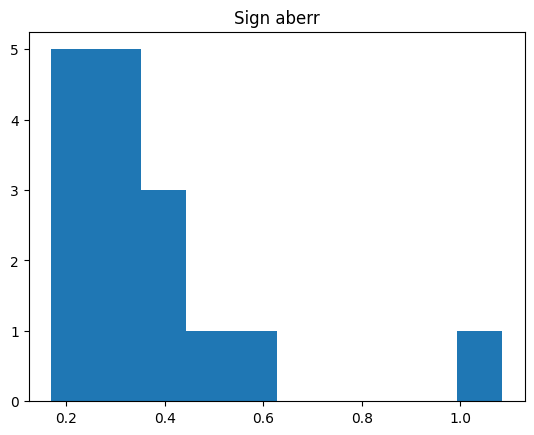

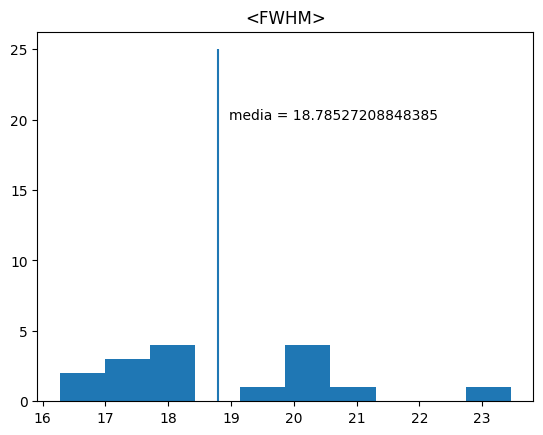

In [8]:
def fwhm(sigma):
    return 2.355*sigma*4

list_tz = []
list_ty = []
list_DeltaFWHM = []
list_aberr = []
list_rms_maps = []
list_av_FWHM = []
list_sign_aberr = []
for i in range(len(list_maps)):
    if list_maps[i]['TZ'].endswith('.5'):
        list_tz.append(float(list_maps[i]['TZ'])) #questo casting permette l'ordinamento dei numeri nel plot
    else:
        list_tz.append(int(list_maps[i]['TZ']))
    list_ty.append(int(list_maps[i]['TY']))
    list_rms_maps.append(float(list_maps[i]['rms_map']))
    list_DeltaFWHM.append(np.abs(fwhm(float(list_maps[i]['sigma_x'][0])) - fwhm(float(list_maps[i]['sigma_y'][0]))))
    list_av_FWHM.append(fwhm(np.max([float(list_maps[i]['sigma_x'][0]), float(list_maps[i]['sigma_y'][0])])))
    list_aberr.append(list_maps[i]['rms_quadrants'])#np.mean([float(x) for x in list_maps[i]['rms_quadrants']]))
    list_sign_aberr.append(float(list_maps[i]['beam_aberr']))

list_DeltaFWHM_norm = []
list_aberr_norm = []
list_av_FWHM_norm = []
list_sign_aberr_norm = []    
for i in range(len(list_maps)):    
    list_DeltaFWHM_norm.append(list_DeltaFWHM[i]/np.max(list_DeltaFWHM))
    list_av_FWHM_norm.append(list_av_FWHM[i]/np.max(list_av_FWHM))
    list_aberr_norm.append(list_aberr[i]/np.max(list_aberr))
    list_sign_aberr_norm.append(list_sign_aberr[i]/np.max(list_sign_aberr))

lin_mapping = np.array(list_DeltaFWHM_norm)**2 + np.array(list_av_FWHM_norm)**2 + np.array(list_aberr_norm)**2 + np.array(list_sign_aberr_norm)**2

plt.hist(list_sign_aberr)
plt.title('Sign aberr')
plt.show()

plt.hist(list_av_FWHM)
plt.vlines(np.average(list_av_FWHM), 0, 25)
plt.text(np.average(list_av_FWHM)+0.01*np.average(list_av_FWHM), 20, 'media = '+str(np.average(list_av_FWHM)))
plt.title('<FWHM>')
plt.show()

[-4, -3, -2, -1] [-1, 0, 1, 2]


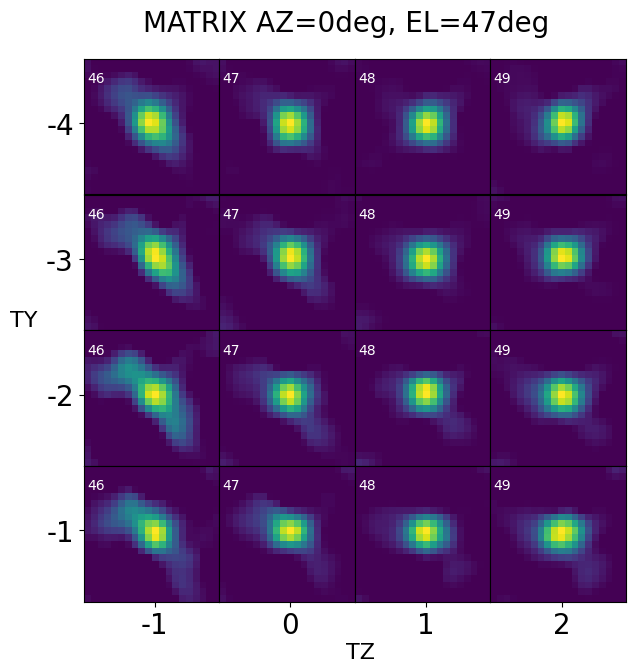

In [9]:

tz = sorted(list(set(list_tz))) #quando da le img bianche nel plot anche se ci sono incollare la lista dal print e togliere i .0
ty = sorted(list(set(list_ty)))

print(ty, tz)

els= []
azs = []
for i in range(len(ty)):
    els.append(float(list_maps[i]['EL']))
    azs.append(float(list_maps[i]['AZ']))

#figsize 30deg (7,7.05), figsize 40deg (7,7.82), figsize 50deg (7,10.07), figsize 60deg (7,6.17), figsize 70deg (6.89,9.9)
fig, ax = plt.subplots( nrows=len(ty), ncols=len(tz), figsize=(7,7.05))#, sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)
plt.suptitle('MATRIX AZ='+ str(int(np.mean(azs))) + 'deg, EL='+ str(int(np.mean(els))) + 'deg', x=0.5, y=0.95, size=20)
fig.text(x=0.5, y=0.03, s='TZ', fontsize=16)
fig.text(x=0.02, y=0.5, s='TY', fontsize=16)
for row in range(len(ty)):
    for col in range(len(tz)):
        for i in range(len(list_maps)):
            idx=None
            delta = 10
            shape_x = delta*2 #np.shape(img[y0-delta:y0+delta, x0-delta:x0+delta])[0]
            shape_y = delta*2 #np.shape(img[y0-delta:y0+delta, x0-delta:x0+delta])[1]
            if list_maps[i]['TZ']==str(tz[col]) and list_maps[i]['TY']==str(ty[row]):
                idx = i
                img = list_maps[idx]['cheat_map']
                img_smooth = ndimage.gaussian_filter(img, sigma=(2, 2), order=0)
                #peak = np.nanargmin(img_smooth)
                peak = np.nanargmax(img_smooth)
                x, y = np.meshgrid(np.arange(0,np.shape(img)[1]), np.arange(0,np.shape(img)[0]))
                x0 = x.ravel()[peak] #x position of the brightest pixel
                y0 = y.ravel()[peak]
                img[np.isnan(img)] = 0
                im = ax[row,col].imshow(img[y0-delta:y0+delta, x0-delta:x0+delta], origin='lower', cmap='viridis')
                ax[row,col].text(0,16, str(list_maps[i]['mean el']), color='white')
                #im = ax[row,col].imshow(img, origin='lower', cmap='viridis')
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
                ax[row,col].set_xticks([])
                ax[row,col].set_xticklabels([])
            if idx==None:
                img = [[np.nan]*shape_x]*shape_y
                x0 = int(shape_x/2)
                y0 = int(shape_y/2)
                im = ax[row,col].imshow(img, origin='lower', cmap='viridis')
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
                ax[row,col].set_xticks([])
                ax[row,col].set_xticklabels([])
        if col == 0:
            ax[row,col].set_yticks([shape_y/2])
            ax[row,col].set_yticklabels([ty[row]], size=20)
        if row==len(ty)-1:
            ax[row,col].set_xticks([shape_x/2])
            ax[row,col].set_xticklabels([tz[col]], size=20)

plt.savefig(dir + date_obs + '-' + hour_obs +'-matrix_'+ str(int(np.mean(els))) + 'deg.png')


#best position a occhio di 60deg TZ -1 TY 0

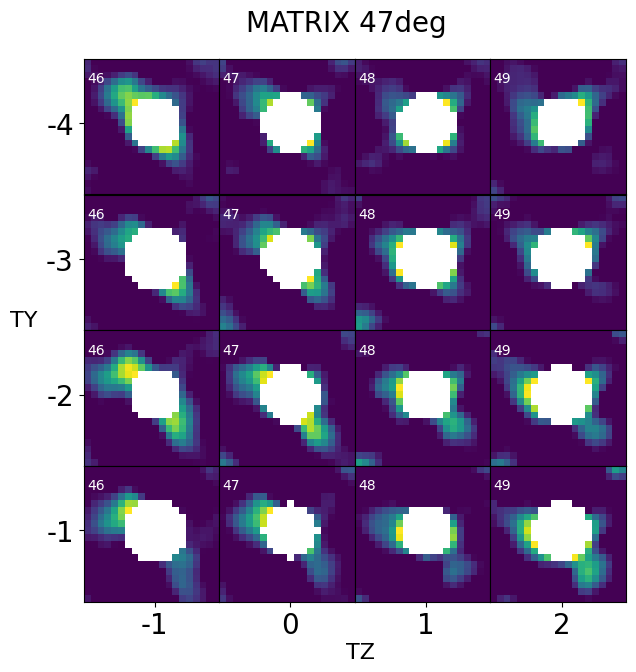

In [10]:
#figsize 30deg (7,7.05), figsize 40deg (7,7.82), figsize 50deg (7,10.07), figsize 60deg (7,6.17), figsize 70deg (6.89,7.05)
fig, ax = plt.subplots( nrows=len(ty), ncols=len(tz), figsize=(7,7.05))#, sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)
plt.suptitle('MATRIX '+ str(int(np.mean(els))) + 'deg', x=0.5, y=0.95, size=20)
fig.text(x=0.5, y=0.03, s='TZ', fontsize=16)
fig.text(x=0.02, y=0.5, s='TY', fontsize=16)
for row in range(len(ty)):
    for col in range(len(tz)):
        for i in range(len(list_maps)):
            idx=None
            if list_maps[i]['TZ']==str(tz[col]) and list_maps[i]['TY']==str(ty[row]):
                idx = i
                img = list_maps[idx]['img_mask_res']
                #limiti img: 30deg [], 40deg [], 50deg [9:-9,9:-9], 60deg [10:-10,10:-10], 70deg 
                im = ax[row,col].imshow(img[9:-9,9:-9], origin='lower', cmap='viridis')
                ax[row,col].text(0,16, str(list_maps[i]['mean el']), color='white')
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
                ax[row,col].set_xticks([])
                ax[row,col].set_xticklabels([])
            if idx==None:
                img = [[np.nan]*shape_x]*shape_y
                x0 = int(shape_x/2)
                y0 = int(shape_y/2)
                im = ax[row,col].imshow(img, origin='lower', cmap='viridis')
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
                ax[row,col].set_xticks([])
                ax[row,col].set_xticklabels([])
        if col == 0:
            ax[row,col].set_yticks([shape_y/2])
            ax[row,col].set_yticklabels([ty[row]], size=20)
        if row==len(ty)-1:
            ax[row,col].set_xticks([shape_x/2])
            ax[row,col].set_xticklabels([tz[col]], size=20)
plt.savefig(dir + date_obs + '-' + hour_obs +'-aberration_matrix_'+ str(int(np.mean(els))) + 'deg.png')



In [11]:
list_maps[0]['rms_quadrants']

0.01677055667804821

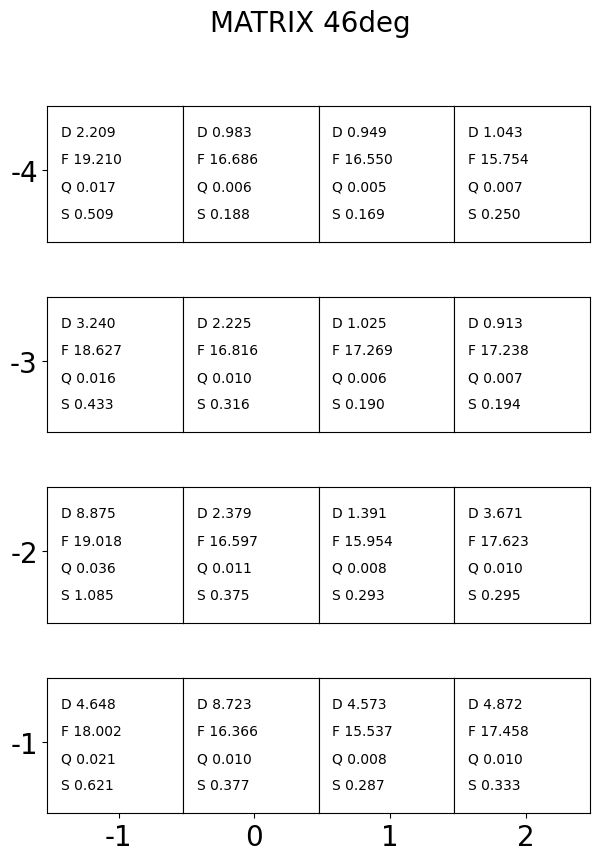

In [12]:
#figsize 30deg (7,7.05), figsize 40deg (7,7.82), figsize 50deg (7,10.07), figsize 60deg (7,6.17), figsize 70deg (7,7.05)
fig, ax = plt.subplots( nrows=len(ty), ncols=len(tz), figsize=(7,9.9))#, sharex=True, sharey=True)
fig.subplots_adjust(wspace=0, hspace=0)
plt.suptitle('MATRIX '+ list_maps[0]['EL'] + 'deg', x=0.5, y=0.95, size=20)
for row in range(len(ty)):
    for col in range(len(tz)):
        for i in range(len(list_maps)):
            idx=None
            if list_maps[i]['TZ']==str(tz[col]) and list_maps[i]['TY']==str(ty[row]):
                idx = i
                img = [[np.nan]*20]*20
                im = ax[row,col].imshow(img, origin='lower', cmap='viridis')
                ax[row,col].text(1.5,11, 'F {:.3f}'.format( fwhm(np.average([float(list_maps[i]['sigma_x'][0]), float(list_maps[i]['sigma_y'][0])]))))
                ax[row,col].text(1.5,15, 'D {:.3f}'.format( np.abs(fwhm(float(list_maps[i]['sigma_x'][0])) - fwhm(float(list_maps[i]['sigma_y'][0])))))
                ax[row,col].text(1.5,7, 'Q {:.3f}'.format( list_maps[i]['rms_quadrants']))
                ax[row,col].text(1.5,3, 'S {:.3f}'.format( float(list_maps[i]['beam_aberr'])))
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
                ax[row,col].set_xticks([])
                ax[row,col].set_xticklabels([])
            if idx==None:
                img = [[np.nan]*20]*20
                im = ax[row,col].imshow(img, origin='lower', cmap='viridis')
                ax[row,col].set_yticks([])
                ax[row,col].set_yticklabels([])
                ax[row,col].set_xticks([])
                ax[row,col].set_xticklabels([])
        if col == 0:
            ax[row,col].set_yticks([20/2])
            ax[row,col].set_yticklabels([ty[row]], size=20)
        if row==len(ty)-1:
            ax[row,col].set_xticks([20/2])
            ax[row,col].set_xticklabels([tz[col]], size=20)
#plt.savefig('./matrix_'+ list_maps[0]['EL'] + 'deg.png')

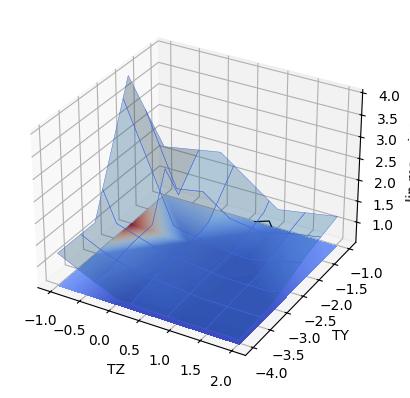

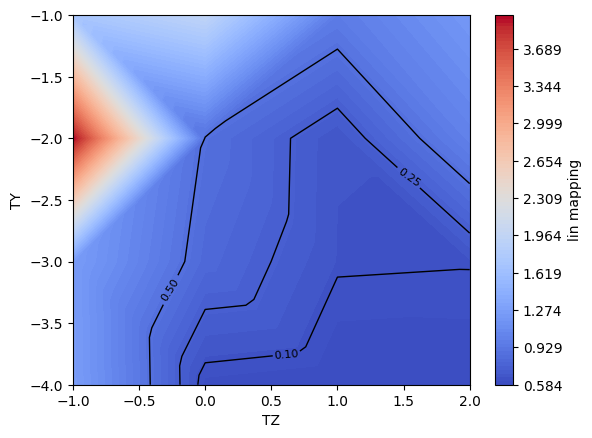

In [13]:
#%matplotlib widget

ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = np.array(list_tz), np.array(list_ty), np.array(lin_mapping)
min = np.min(lin_mapping)
max = np.max(lin_mapping)

levels = [min+0.1*min, min+0.25*min, min+0.5*min]

nx = 10*int(np.sqrt(len(list_ty)))
xg = np.linspace(X.min(), X.max(), nx)
yg = np.linspace(Y.min(), Y.max(), nx)
xgrid, ygrid = np.meshgrid(xg, yg)
ctr_f = griddata((X, Y), Z, (xgrid, ygrid), method='linear')

# Plot the 3D surface  
ax.plot_surface(xgrid, ygrid, ctr_f, edgecolor='royalblue', lw=0.3, rstride=8, cstride=8, alpha=0.3) #edgecolor='royalblue' #cmap='coolwarm'
# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph
ax.contourf(xgrid, ygrid, ctr_f, zdir='z',offset=np.min(Z)-0.1, cmap='coolwarm', levels=np.linspace(min, max, 150))
cs = ax.contour(xgrid, ygrid, ctr_f, levels=levels, colors=('k',),
              linewidths=(1,),
              origin='lower')
#ax.contourf(xgrid, ygrid, ctr_f, zdir='x',offset=np.min(X), cmap='coolwarm')
#ax.contourf(xgrid, ygrid, ctr_f, zdir='y',offset=np.max(Y), cmap='coolwarm')
ax.set(xlabel='TZ', ylabel='TY', zlabel='lin mapping')
plt.show()

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1) 
im = ax.contourf(xgrid, ygrid, ctr_f, cmap=cm.coolwarm, levels=np.linspace(min, max, 100), origin='lower')

cs = ax.contour(xgrid, ygrid, ctr_f, levels=levels, colors=('k',),
              linewidths=(1,),
              origin='lower')
plt.clabel(cs, fmt=lambda x: f'{(x -min)/min:.2f}', colors='k', fontsize=8) #'%.3f'
ax.set(xlabel='TZ', ylabel='TY')
cbar = plt.colorbar(im)
cbar.set_label('lin mapping')
plt.show()


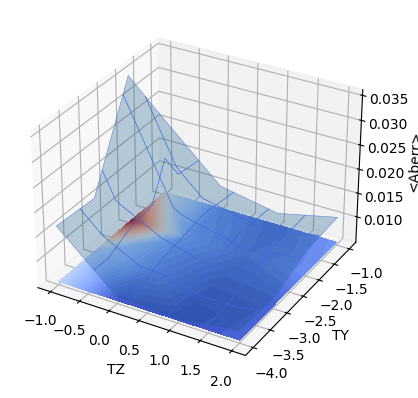

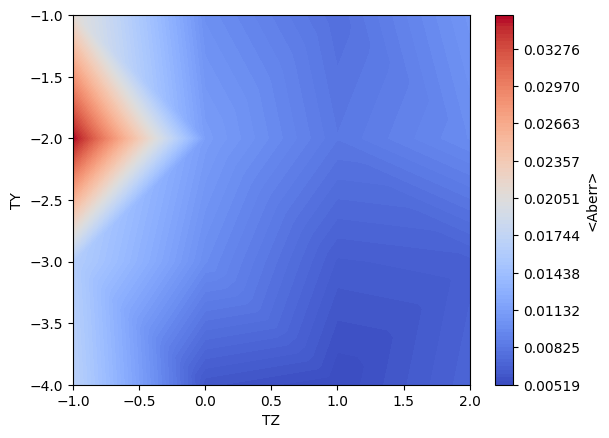

In [14]:
#%matplotlib widget

ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = np.array(list_tz), np.array(list_ty), np.array(list_aberr)
min = np.min(list_aberr)
max = np.max(list_aberr)

nx = 10*int(np.sqrt(len(list_ty)))
xg = np.linspace(X.min(), X.max(), nx)
yg = np.linspace(Y.min(), Y.max(), nx)
xgrid, ygrid = np.meshgrid(xg, yg)
ctr_f = griddata((X, Y), Z, (xgrid, ygrid), method='linear')

# Plot the 3D surface  
ax.plot_surface(xgrid, ygrid, ctr_f, edgecolor='royalblue', lw=0.3, rstride=8, cstride=8, alpha=0.3) #edgecolor='royalblue' #cmap='coolwarm'
# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph
ax.contourf(xgrid, ygrid, ctr_f, zdir='z',offset=np.min(Z), cmap='coolwarm', levels=np.linspace(min, max, 50))
#ax.contourf(xgrid, ygrid, ctr_f, zdir='x',offset=np.min(X), cmap='coolwarm')
#ax.contourf(xgrid, ygrid, ctr_f, zdir='y',offset=np.max(Y), cmap='coolwarm')
ax.set(xlabel='TZ', ylabel='TY', zlabel='<Aberr>')
plt.show()


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1) 
im = ax.contourf(xgrid, ygrid, ctr_f, cmap=cm.coolwarm, levels=np.linspace(min, max, 100))
ax.set(xlabel='TZ', ylabel='TY')
cbar = plt.colorbar(im)
cbar.set_label('<Aberr>')
plt.show()

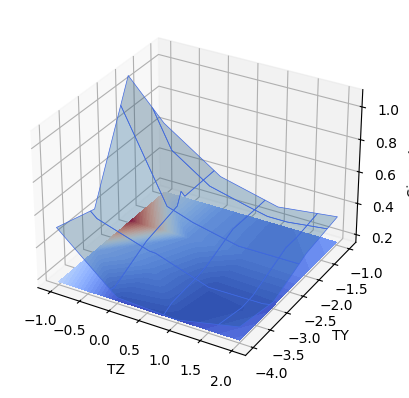

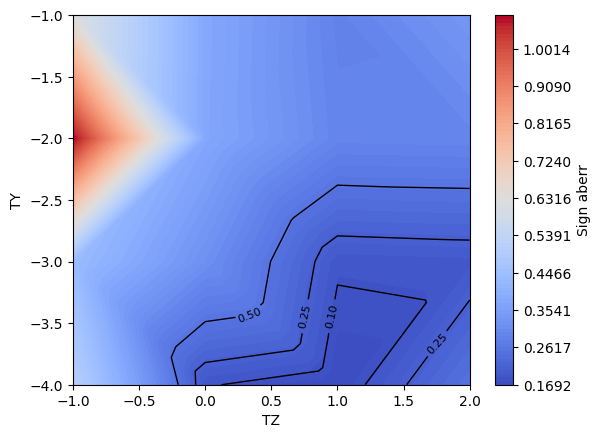

In [15]:
ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = np.array(list_tz), np.array(list_ty), np.array(list_sign_aberr)
min = np.min(list_sign_aberr)
max = np.max(list_sign_aberr)
nx = 7*int(np.sqrt(len(list_ty)))
xg = np.linspace(X.min(), X.max(), nx)
yg = np.linspace(Y.min(), Y.max(), nx)
xgrid, ygrid = np.meshgrid(xg, yg)
ctr_f = griddata((X, Y), Z, (xgrid, ygrid), method='linear')

# Plot the 3D surface  
ax.plot_surface(xgrid, ygrid, ctr_f, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8, alpha=0.3, cmap=None)
# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph
ax.contourf(xgrid, ygrid, ctr_f, zdir='z', cmap='coolwarm', offset=min, levels=np.linspace(min,max,50))# offset=-100,
#ax.contourf(X, Y, Z, zdir='x', cmap='coolwarm')# offset=-40,
#ax.contourf(X, Y, Z, zdir='y', cmap='coolwarm')# offset=40,
ax.set(xlabel='TZ', ylabel='TY', zlabel='Sign aberr') #xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),
plt.show()


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1) 
im =ax.contourf(xgrid, ygrid, ctr_f, cmap=cm.coolwarm, levels=np.linspace(min,max,100))
levels = [min+0.1*min, min+0.25*min, min+0.5*min]
cs = ax.contour(xgrid, ygrid, ctr_f, levels=levels, colors=('k',),
              linewidths=(1,),
              origin='lower')
plt.clabel(cs, fmt=lambda x: f'{(x -min)/min:.2f}', colors='k', fontsize=8) #'%.3f'
ax.set(xlabel='TZ', ylabel='TY')
cbar = plt.colorbar(im)
cbar.set_label('Sign aberr')
plt.savefig(dir + date_obs + '-' + hour_obs +'-phot_index_'+ str(int(np.mean(els))) + 'deg.png')
plt.show()

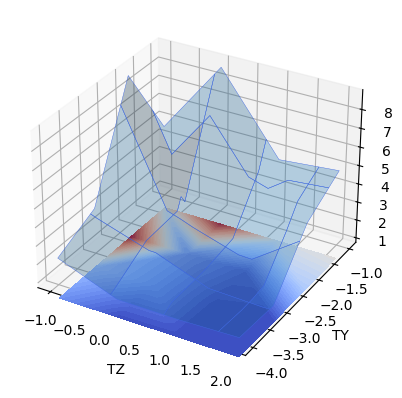

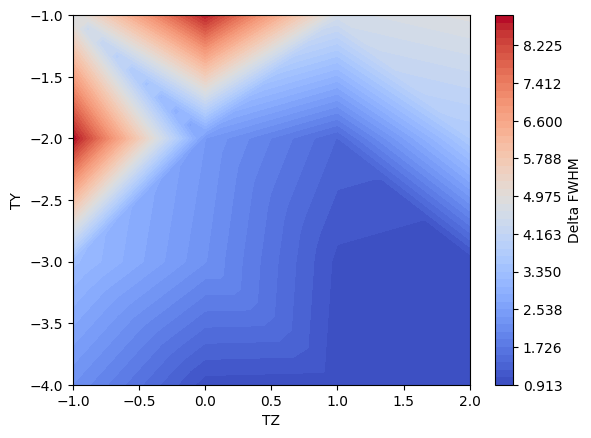

In [16]:
ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = np.array(list_tz), np.array(list_ty), np.array(list_DeltaFWHM)
min = np.min(list_DeltaFWHM)
max = np.max(list_DeltaFWHM)
nx = 7*int(np.sqrt(len(list_ty)))
xg = np.linspace(X.min(), X.max(), nx)
yg = np.linspace(Y.min(), Y.max(), nx)
xgrid, ygrid = np.meshgrid(xg, yg)
ctr_f = griddata((X, Y), Z, (xgrid, ygrid), method='linear')

# Plot the 3D surface  
ax.plot_surface(xgrid, ygrid, ctr_f, edgecolor='royalblue', alpha=0.3, linewidth=0.3, rstride=8, cstride=8)

# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph
ax.contourf(xgrid, ygrid, ctr_f, zdir='z', cmap='coolwarm', offset=0, levels=np.linspace(min,max,50))# offset=-100,
#ax.contourf(X, Y, Z, zdir='x', cmap='coolwarm')# offset=-40,
#ax.contourf(X, Y, Z, zdir='y', cmap='coolwarm')# offset=40,
ax.set(xlabel='TZ', ylabel='TY', zlabel='Delta FWHM') #xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),
plt.show()

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1) 
im =ax.contourf(xgrid, ygrid, ctr_f, cmap=cm.coolwarm, levels=np.linspace(min, max, 50))
ax.set(xlabel='TZ', ylabel='TY')
cbar = plt.colorbar(im)
cbar.set_label('Delta FWHM')
plt.show()

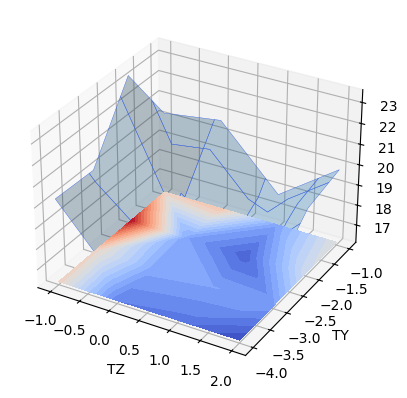

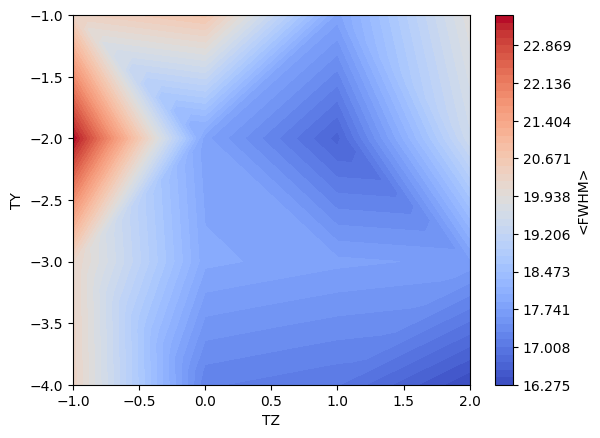

In [17]:
ax = plt.figure().add_subplot(projection='3d')
X, Y, Z = np.array(list_tz), np.array(list_ty), np.array(list_av_FWHM)
min = np.min(list_av_FWHM)
max = np.max(list_av_FWHM)
nx = 7*int(np.sqrt(len(list_ty)))
xg = np.linspace(X.min(), X.max(), nx)
yg = np.linspace(Y.min(), Y.max(), nx)
xgrid, ygrid = np.meshgrid(xg, yg)
ctr_f = griddata((X, Y), Z, (xgrid, ygrid), method='linear')

# Plot the 3D surface  
ax.plot_surface(xgrid, ygrid, ctr_f, edgecolor='royalblue', alpha=0.3, linewidth=0.3, rstride=8, cstride=8)
# Plot projections of the contours for each dimension.  By choosing offsets
# that match the appropriate axes limits, the projected contours will sit on
# the 'walls' of the graph
ax.contourf(xgrid, ygrid, ctr_f, zdir='z', cmap='coolwarm', offset=min, levels=np.linspace(min, max, 25))
#ax.contourf(X, Y, Z, zdir='x', cmap='coolwarm')# offset=-40,
#ax.contourf(X, Y, Z, zdir='y', cmap='coolwarm')# offset=40,
ax.set(xlabel='TZ', ylabel='TY', zlabel='<FWHM>') #xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100),
plt.show()

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1) 
im =ax.contourf(xgrid, ygrid, ctr_f, cmap=cm.coolwarm, levels=np.linspace(min, max, 50))
ax.set(xlabel='TZ', ylabel='TY')
cbar = plt.colorbar(im)
cbar.set_label('<FWHM>')
plt.show()

In [18]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
TARGET  = 'MARS    '                                                            
HIERARCH Date = '20250330'                                                      
HIERARCH Mean Elevation = 48.15494464139232 / deg                               
HIERARCH Schedule Name = 'MATRIX_SCAN_MARS_OTFC_40deg_ridotta_2025089212702'    
HIERARCH TY = '2       '                                                        
HIERARCH RA center scan = 2.01062965393066 / Source RA at J2000 (radians)       
HIERARCH dec center scan = 0.421452283859253 / Source dec at J2000 (radians     
HIERARCH Pixel size (arcsec) = 3 / arcsec                                       
HIERARCH Projection = 'SIN--

In [ ]:
'''
dir = '/Users/eleonora/Desktop/matrix nuove/'
sub_dir = os.listdir(dir)

sub_dir

ln = []
count = 1
n=0
for subdir in sub_dir:
    n += len(os.listdir(dir+subdir))
    
    for name in os.listdir(dir+subdir):
        #print(name)
        with fits.open(dir + subdir + '/' + name) as hdul:
            meanEL = hdul['PRIMARY'].header['HIERARCH Mean Elevation']
            if meanEL>=70:
                new_name = name.split('.fits')[0] + '_70deg'
            elif meanEL<70 and meanEL>=60:
                new_name = name.split('.fits')[0] +  '_60deg'
            elif meanEL<60 and meanEL>=50:
                new_name = name.split('.fits')[0] +  '_50deg'
            elif meanEL<50 and meanEL>=40:
                new_name = name.split('.fits')[0] +  '_40deg'
            elif meanEL<40:
                new_name = name.split('.fits')[0] +  '_30deg'
            
            if new_name + '.fits' in ln:
                new_name = new_name + '_' + str(1)
            
            if new_name + '_1.fits' in ln:
                new_name = new_name + '_' + str(2)
                
            ln.append(new_name + '.fits')

        os.rename(dir + subdir + '/' + name, dir + subdir + '/' + new_name+ '.fits')
print('Number of maps: ', n)
print('Number of renamed maps:', len(ln)) 
'''

"\ndir = '/Users/eleonora/Desktop/matrix nuove/'\nsub_dir = os.listdir(dir)\n\nsub_dir\n\nln = []\ncount = 1\nn=0\nfor subdir in sub_dir:\n    n += len(os.listdir(dir+subdir))\n    \n    for name in os.listdir(dir+subdir):\n        #print(name)\n        with fits.open(dir + subdir + '/' + name) as hdul:\n            meanEL = hdul['PRIMARY'].header['HIERARCH Mean Elevation']\n            if meanEL>=70:\n                new_name = name.split('.fits')[0] + '_70deg'\n            elif meanEL<70 and meanEL>=60:\n                new_name = name.split('.fits')[0] +  '_60deg'\n            elif meanEL<60 and meanEL>=50:\n                new_name = name.split('.fits')[0] +  '_50deg'\n            elif meanEL<50 and meanEL>=40:\n                new_name = name.split('.fits')[0] +  '_40deg'\n            elif meanEL<40:\n                new_name = name.split('.fits')[0] +  '_30deg'\n            \n            if new_name + '.fits' in ln:\n                new_name = new_name + '_' + str(1)\n           

In [ ]:
a = 'aa'
b = ['bb', 'bb1', 'bb2']
c = ['cc', 'cc1', 'cc2']
d = 'dd'

fnames = [(m, e) for m, e in zip(a, d)]
print(fnames[0])

('a', 'd')
